In [1]:
import skimage.transform
from skimage.io import imread
from skimage.color import rgb2lab, lab2rgb, rgb2gray, gray2rgb
import random
from sklearn.model_selection import train_test_split

import os
import numpy as np
import cv2
import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, UpSampling2D, Dense,InputLayer, Concatenate,Reshape,RepeatVector
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.inception_v3 import preprocess_input

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
colorful_path = '/kaggle/input/colorization-data/ColorfulOriginal/ColorfulOriginal/ColorfulOriginal'
gray_path = '/kaggle/input/colorization-data/GrayScale/NCDataset/Gray'

# Preprocess Data

In [3]:
def image_process(img, gr_img):
    img = imread(img)
    gr_img = imread(gr_img)

    im = img.copy()
    im = rgb2lab(im)

    # centered and scaled image in order to have a interval of -1,1
    L_channel = im[:,:,0]-50; L_channel = L_channel/50
    A_channel = im[:,:,1]/128
    B_channel = im[:,:,2]/128

    # Encoder path
    Encoder_image = skimage.transform.resize(L_channel,(224,224,1),anti_aliasing = True)

    # Extractor path
    Extractor_image = gr_img
    Extractor_image = gray2rgb(Extractor_image)
    Extractor_image = skimage.transform.resize(Extractor_image,(299,299,3),anti_aliasing = True)*255
    Extractor_image = preprocess_input(Extractor_image)


    # AB channel path
    A_channel = skimage.transform.resize(A_channel,(224,224,1))
    B_channel = skimage.transform.resize(B_channel,(224,224,1))
    AB_channel = np.concatenate([A_channel,B_channel],axis=-1)

    return Encoder_image,Extractor_image,AB_channel    

In [4]:
X_train_enc, X_val_enc, X_train_ex, X_val_ex = [], [] ,[] , []
y_train, y_val = [], []

for folder in os.listdir(colorful_path):
    folder_path = os.path.join(colorful_path, folder)
    gray_img_path = os.path.join(gray_path, folder)
    
    train_rate = int(0.8 * len(os.listdir(folder_path)))
    train_files = random.sample(os.listdir(folder_path), train_rate)
    val_files = list(set(os.listdir(folder_path)) - set(train_files))
    
    for file in train_files:
        enc_path = os.path.join(folder_path, file)
        ex_path = os.path.join(gray_img_path, file)
        X_enc, X_ex ,y =  image_process(enc_path, ex_path)
        X_train_enc.append(X_enc); X_train_ex.append(X_ex); y_train.append(y)
        
    for file in val_files:
        enc_path = os.path.join(folder_path, file)
        ex_path = os.path.join(gray_img_path, file)
        X_enc, X_ex ,y =  image_process(enc_path, ex_path)
        X_val_enc.append(X_enc); X_val_ex.append(X_ex); y_val.append(y)

# Prepare Model

In [5]:
# def Encoder_model():
#     model = Sequential(name="Encoder")
#     model.add(InputLayer(input_shape=(224, 224, 1)))
#     model.add(Conv2D(64, (3, 3), activation="relu", padding="same", strides=2))
#     model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
#     model.add(Conv2D(128, (3, 3), activation="relu", padding="same", strides=2))
#     model.add(Conv2D(256, (3, 3), activation="relu", padding="same"))
#     model.add(Conv2D(256, (3, 3), activation="relu", padding="same", strides=2))
#     model.add(Conv2D(512, (3, 3), activation="relu", padding="same"))
#     model.add(Conv2D(512, (3, 3), activation="relu", padding="same"))
#     model.add(Conv2D(256, (3, 3), activation="relu", padding="same"))
#     return model

def Encoder_model():
    model = Sequential(name="Encoder")
    model.add(InputLayer(input_shape=(224, 224, 1)))
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same", strides=2))
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(Conv2D(256, (3, 3), activation="relu", padding="same", strides=2))
    model.add(Conv2D(512, (3, 3), activation="relu", padding="same"))
    model.add(Conv2D(256, (3, 3), activation="relu", padding="same", strides=2))
    return model


In [6]:
inception = tf.keras.applications.InceptionV3(weights='imagenet')

96112376/96112376 [==============================] - 0s 0us/step


In [7]:
def fusion(encoder_output, inception_output):
    IR_v2_output = RepeatVector(28*28)(inception_output)
    R_v2_output = Reshape((28,28,1000))(IR_v2_output)
    return tf.keras.layers.Concatenate(axis=-1)([encoder_output, R_v2_output])

In [8]:
# def Decoder_model(fusion):
#     model = Conv2D(256, (1, 1), activation="relu", padding="same",input_shape = (28,28,1256))(fusion)
#     model = Conv2D(128, (3, 3), activation="relu", padding="same")(model)
#     model = UpSampling2D((2, 2))(model)
#     model = Conv2D(64, (3, 3), activation="relu", padding="same")(model)
#     model = Conv2D(64, (3, 3), activation="relu", padding="same")(model)
#     model = UpSampling2D((2, 2))(model)
#     model = Conv2D(32, (3, 3), activation="relu", padding="same")(model)
#     model = Conv2D(2, (3, 3), activation="tanh", padding="same")(model)
#     model = UpSampling2D((2, 2))(model)
#     return model

def Decoder_model(fusion):
    model = Conv2D(256, (1, 1), activation="relu", padding="same",input_shape = (28,28,1256))(fusion)
    model = Conv2D(128, (3, 3), activation="relu", padding="same")(model)
    model = UpSampling2D((2, 2))(model)
    model = Conv2D(64, (3, 3), activation="relu", padding="same")(model)
    model = UpSampling2D((2, 2))(model)
    model = Conv2D(32, (3, 3), activation="relu", padding="same")(model)
    model = Conv2D(2, (3, 3), activation="tanh", padding="same")(model)
    model = UpSampling2D((2, 2))(model)
    return model

In [9]:
IR_v3_base_model = inception
IR_v3_base_model.trainable = False

# Set Inception ResNet V3 layer to be untrainable
Encoder_path = Encoder_model()

# Fuse the stacked extractor layer with the Encoder output     
Fusion_output = fusion(Encoder_path.output, IR_v3_base_model.output)

# Add the Decoder model
Decoder_output = Decoder_model(Fusion_output)

# Final model
Final_model = Model([Encoder_path.input, IR_v3_base_model.input],Decoder_output)

# Final_model.summary()

# Train

In [10]:
BATCH_SIZE = 32
EPOCHS = 10

In [11]:
X_train_enc = tf.convert_to_tensor(X_train_enc)
X_train_ex = tf.convert_to_tensor(X_train_ex)
X_val_enc = tf.convert_to_tensor(X_val_enc)
X_val_ex = tf.convert_to_tensor(X_val_ex)
y_train = tf.convert_to_tensor(y_train)
y_val = tf.convert_to_tensor(y_val)

In [12]:
# opt = tf.keras.optimizers.Adam(lr=1e-3)
Final_model.compile(optimizer='Adam',loss='mse',metrics = ['accuracy'])

In [13]:
history = Final_model.fit([X_train_enc, X_train_ex], 
                          y_train, 
                          validation_data=([X_val_enc, X_val_ex], y_val),
                          epochs = EPOCHS, batch_size=BATCH_SIZE)

Final_model.save('/kaggle/working/deep_color_model.h5')

Epoch 1/10
18/18 [==============================] - 33s 768ms/step - loss: 0.0363 - accuracy: 0.6737 - val_loss: 0.0335 - val_accuracy: 0.7012
Epoch 2/10
18/18 [==============================] - 5s 281ms/step - loss: 0.0237 - accuracy: 0.7990 - val_loss: 0.0502 - val_accuracy: 0.3314
Epoch 3/10
18/18 [==============================] - 5s 281ms/step - loss: 0.0247 - accuracy: 0.5101 - val_loss: 0.0236 - val_accuracy: 0.8115
Epoch 4/10
18/18 [==============================] - 6s 315ms/step - loss: 0.0144 - accuracy: 0.7349 - val_loss: 0.0151 - val_accuracy: 0.8484
Epoch 5/10
18/18 [==============================] - 5s 282ms/step - loss: 0.0140 - accuracy: 0.7886 - val_loss: 0.0390 - val_accuracy: 0.5026
Epoch 6/10
18/18 [==============================] - 5s 283ms/step - loss: 0.0117 - accuracy: 0.7696 - val_loss: 0.0142 - val_accuracy: 0.8598
Epoch 7/10
18/18 [==============================] - 5s 281ms/step - loss: 0.0092 - accuracy: 0.8341 - val_loss: 0.0175 - val_accuracy: 0.6233
Epoch

# Test

In [14]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

In [15]:
model = load_model('/kaggle/input/better-weigth/deep_color_model.h5')

In [16]:
img_path = '/kaggle/input/colorization-data/ColorfulOriginal/ColorfulOriginal/ColorfulOriginal/Plum/Plum10.jpg'
gray = '/kaggle/input/colorization-data/GrayScale/NCDataset/Gray/Plum/Plum10.jpg'

In [17]:
image_rgb = np.array((imread(img_path)))
image_gray = np.array((imread(gray)))

In [18]:
Encoder_image, Extractor_image,AB_channel = image_process(img_path, gray)

Encoder_image = Encoder_image.reshape((1,224,224,1))
Extractor_image = Extractor_image.reshape((1,299,299,3))

predicted = Final_model.predict([[Encoder_image],[Extractor_image]], verbose=0)

Encoder_image = Encoder_image*50; Encoder_image = Encoder_image + 50
predicted = predicted * 128

In [19]:
Final_predicted_image = np.concatenate((Encoder_image,predicted),axis=-1)
Final_predicted_image = lab2rgb(Final_predicted_image[0])
Final_predicted_image = skimage.transform.resize(Final_predicted_image,(image_rgb.shape[0],image_rgb.shape[1]))

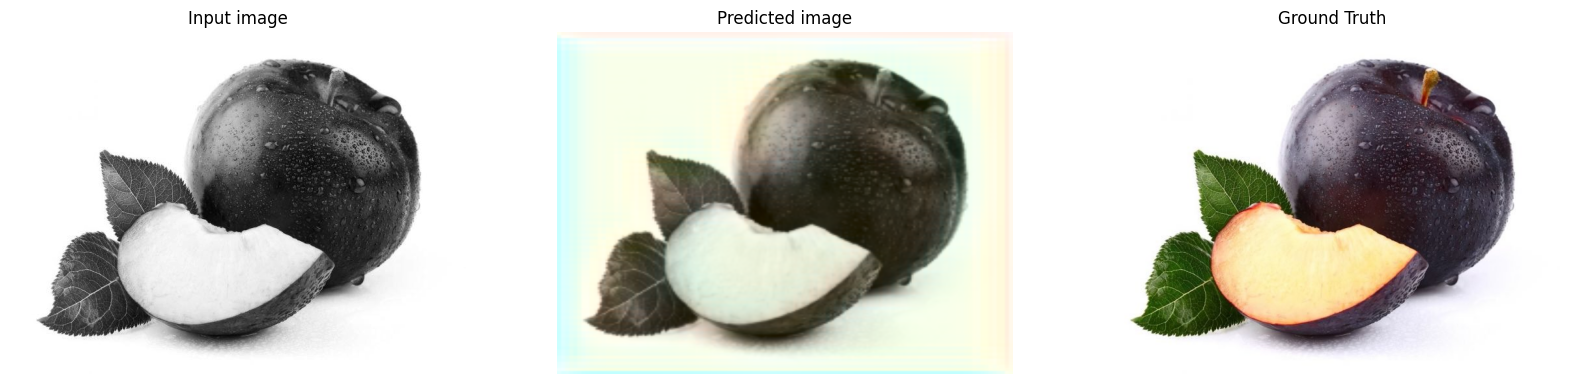

In [20]:
fig = plt.figure(figsize=(20,10))

ax = fig.add_subplot(1,3,1)
ax.set_title('Input image')
ax.imshow(image_gray,cmap='gray')
ax.axis('off')

ax = fig.add_subplot(1,3,2)
ax.set_title('Predicted image')
ax.imshow(Final_predicted_image)
ax.axis('off')

ax = fig.add_subplot(1,3,3)
ax.set_title('Ground Truth')
ax.axis('off')
ax.imshow(image_rgb)

plt.show()